In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from causallearn.search.ConstraintBased.PC import pc
import contextlib
from io import StringIO
import re
from pathlib import Path
import os
import networkx as nx
from networkx.drawing.nx_pydot import graphviz_layout
from collections import defaultdict

In [5]:
def extract_pc_edges(data, alpha=0.05, indep_test='fisherz'):
    """
    Run PC algorithm on a subsample and extract edges.
    
    Returns:
    --------
    edges : List[Tuple[int, int]]
        List of edges found by PC
    n_edges : int
        Number of edges found
    """
    
    # Suppress verbose output
    with contextlib.redirect_stdout(StringIO()):
        cg = pc(data, alpha=alpha, indep_test=indep_test, verbose=False)
    
    # Extract edges from the graph
    edges = []
    adj_matrix = cg.G.graph
    
    for i in range(adj_matrix.shape[0]):
        for j in range(i + 1, adj_matrix.shape[0]):
            if adj_matrix[i,j] != 0:
                edges.append((i, j))
    
    return edges, len(edges)

def stability_selection(data, n_subsamples=100, subsample_ratio=0.5, alpha=0.05, indep_test='fisherz'):
    """
    Run stability selection procedure on PC algorithm.
    
    Parameters:
    -----------
    data : np.ndarray
        The dataset (n_samples x n_variables)
    n_subsamples : int
        Number of subsamples to create
    subsample_ratio : float
        Fraction of data to use in each subsample
    alpha : float
        Significance level for PC algorithm
    indep_test : str
        Independence test for PC algorithm
        
    Returns:
    --------
    edge_counts : dict
        Count of how many times each edge appeared
    selection_probabilities : dict
        Selection probability for each edge
    subsample_edge_counts : list
        Number of edges found in each subsample
    """
    
    N, p = data.shape
    subsample_size = int(N * subsample_ratio)

    # full_edges, _ = extract_pc_edges(data, alpha, indep_test)

    with contextlib.redirect_stdout(StringIO()) as captured:
        full_cg = pc(data, alpha=alpha, indep_test=indep_test, verbose=True)
    full_verbose_output = captured.getvalue()
    
    # Extract edges from the graph
    full_edges = []
    adj_matrix = full_cg.G.graph
    
    for i in range(adj_matrix.shape[0]):
        for j in range(i + 1, adj_matrix.shape[0]):
            if adj_matrix[i,j] != 0:
                full_edges.append((i, j))
    
    edge_counts = defaultdict(int)
    subsample_edge_counts = []
    
    for i in range(n_subsamples):
        if (i + 1) % 20 == 0:
            print(f"Completed {i + 1}/{n_subsamples} subsamples")
        
        # Run PC on subsample
        subsample_indices = np.random.choice(N, size=subsample_size, replace=False)
        subsample_data = data[subsample_indices, :]
        edges, n_edges = extract_pc_edges(subsample_data, alpha, indep_test)
        subsample_edge_counts.append(n_edges)
        
        # Count the number of edge occurrences
        for edge in edges:
            edge_counts[edge] += 1
    
    # Calculate selection probabilities
    selection_probabilities = {edge: count / n_subsamples for edge, count in edge_counts.items()}
    # selection_probabilities = {edge: edge_counts.get(edge, 0) / n_subsamples for edge in full_edges}
    
    print("Stability selection complete.")
    print(f"Average edges per subsample: {np.mean(subsample_edge_counts):.2f}")
    print(f"Total unique edges found: {len(selection_probabilities)}")
    
    return full_verbose_output, edge_counts, selection_probabilities, subsample_edge_counts

def calculate_cutoff(p, subsample_edge_counts, q=None):
    """
    Calculate the cutoff threshold to control Per-Family Error Rate (PFER).
    
    Parameters:
    -----------
    subsample_edge_counts : list
        Number of edges found in each subsample
    pfer : float
        Desired upper bound on expected number of false positives
    q : float, optional
        Average number of selected variables per subsample. If None, uses observed average.
    
    Returns:
    --------
    cutoff : float
        The required cutoff threshold
    """

    # Use the empirical average of the frequencies of each edge if q is not provided
    if q is None:
        q = np.mean(subsample_edge_counts)
    print("q is:", q)
    
    pi_thr = 0.5 + (q**2)/(0.05*p*(p-1))
    print("Calculated pi_thr before bounding:", pi_thr)
    pi_thr = max(0.6, min(0.9, pi_thr))
    return pi_thr

def select_stable_edges(p, selection_probabilities, subsample_edge_counts, cutoff=None):
    """
    Select stable edges based on cutoff threshold.
    
    Parameters:
    -----------
    selection_probabilities : dict
        Selection probability for each edge
    subsample_edge_counts : list
        Number of edges found in each subsample
    cutoff : float, optional
        Selection probability threshold. If None, calculated from PFER.
    pfer : float
        Desired PFER if cutoff is not provided
        
    Returns:
    --------
    stable_edges : list
        List of edges with selection probability >= cutoff
    unstable_edges : list
        List of edges with selection probability < cutoff
    actual_cutoff : float
        The cutoff threshold used
    """
    if cutoff is None:
        cutoff = calculate_cutoff(p, subsample_edge_counts)
    
    stable_edges = [
        edge for edge, prob in selection_probabilities.items() 
        if prob >= cutoff
    ]
    
    unstable_edges = [
        edge for edge, prob in selection_probabilities.items() 
        if prob < cutoff
    ]
    
    print(f"\nStability Selection Results:")
    print(f"Cutoff threshold: {cutoff:.3f}")
    print(f"Stable edges: {len(stable_edges)}")
    print(f"Unstable edges: {len(unstable_edges)}")
    
    return stable_edges, unstable_edges, cutoff

def get_pvalues_by_stability(stable_edges, unstable_edges, full_verbose_output):
    """
    Categorize p-values by stable vs unstable edges using the PC output from the first run.
    
    Parameters:
    -----------
    stable_edges : list
        List of edges determined to be stable
    unstable_edges : list
        List of edges determined to be unstable
    full_verbose_output : str
        Captured verbose output from the PC run on the full dataset
    full_cg : CausalGraph
        The PC object from the full dataset run
        
    Returns:
    --------
    stable_pvalues : list
        P-values from tests involving stable edges
    unstable_pvalues : list
        P-values from tests involving unstable edges
    other_pvalues : list
        P-values from edges not categorized as stable/unstable
    full_cg : CausalGraph
        The same PC object, for visualization
    """
    print("Extracting p-values by stability classes...")
    print(f"Stable edges: {stable_edges}")
    print(f"Unstable edges: {unstable_edges}")
    
    stable_edges_set = set(stable_edges)
    unstable_edges_set = set(unstable_edges)
    
    # Parse p-values from the previously captured verbose output
    pattern = r'(\d+)\s+dep\s+(\d+)\s+\|\s+.*?\s+with\s+p-value\s+([\d\.e-]+)'
    matches = re.findall(pattern, full_verbose_output)
    
    print(f"Found {len(matches)} dependency tests with p-values")
    
    stable_pvalues = []
    unstable_pvalues = []
    other_pvalues = []
    
    for match in matches:
        var1, var2, p_val = int(match[0]), int(match[1]), float(match[2])
        edge = (min(var1, var2), max(var1, var2))
        
        if edge in stable_edges_set:
            stable_pvalues.append(p_val)
        elif edge in unstable_edges_set:
            unstable_pvalues.append(p_val)
        else:
            other_pvalues.append(p_val)
    
    print(f"P-values from stable edges: {len(stable_pvalues)}")
    print(f"P-values from unstable edges: {len(unstable_pvalues)}")
    print(f"P-values from other edges: {len(other_pvalues)}")
    
    return stable_pvalues, unstable_pvalues, other_pvalues

def plot_selection_probabilities(selection_probabilities, cutoff=None, figsize=(12, 6)):
    """Plot histogram and sorted plot of selection probabilities."""
    probs = list(selection_probabilities.values())
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    
    # Histogram of selection probabilities
    ax1.hist(probs, bins=30, alpha=0.7, edgecolor='black', color='skyblue')
    if cutoff is not None:
        ax1.axvline(cutoff, color='red', linestyle='--', linewidth=2, 
                   label=f'Cutoff = {cutoff:.3f}')
        ax1.legend()
    ax1.set_xlabel('Selection Probability', fontsize=12)
    ax1.set_ylabel('Number of Edges', fontsize=12)
    ax1.set_title('Distribution of Edge Selection Probabilities', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    
    # Sorted probabilities
    sorted_probs = sorted(probs, reverse=True)
    ax2.plot(range(len(sorted_probs)), sorted_probs, 'b-', linewidth=2)
    if cutoff is not None:
        ax2.axhline(cutoff, color='red', linestyle='--', linewidth=2, 
                   label=f'Cutoff = {cutoff:.3f}')
        ax2.legend()
    ax2.set_xlabel('Edge Rank', fontsize=12)
    ax2.set_ylabel('Selection Probability', fontsize=12)
    ax2.set_title('Selection Probabilities (Ranked)', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def plot_p_value_distribution(p_values):
    """
    Plots the distribution of p-values.

    Parameters:
    - p_values: list of p-values
    """
    plt.hist(p_values, bins=max(int(np.sqrt(len(p_values))),1), edgecolor='black')
    plt.title('P-value Distribution from PC Algorithm')
    plt.xlabel('P-value')
    plt.ylabel('Frequency')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

...

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

Completed 100/100 subsamples
Stability selection complete.
Average edges per subsample: 93.60
Total unique edges found: 166
q is: 93.6
Calculated pi_thr before bounding: 18.19890909090909

Stability Selection Results:
Cutoff threshold: 0.900
Stable edges: 83
Unstable edges: 83

Analyzing p-values from stable vs unstable edges...
Extracting p-values by stability classes...
Stable edges: [(0, 99), (1, 2), (2, 3), (3, 4), (4, 5), (4, 95), (5, 94), (6, 7), (7, 8), (7, 92), (8, 9), (9, 10), (10, 11), (11, 12), (12, 13), (13, 14), (14, 15), (15, 16), (18, 19), (20, 21), (21, 22), (22, 23), (23, 24), (24, 25), (25, 26), (26, 27), (27, 28), (28, 29), (29, 30), (30, 31), (32, 33), (33, 34), (34, 35), (35, 36), (37, 38), (39, 40), (40, 41), (41, 42), (42, 43), (43, 44), (45, 46), (46, 47), (47, 48), (48, 49), (50, 51), (52, 53), (53, 54), (54, 55), (55, 56), (57, 58), (58, 59), (59, 60), (60, 61), (61, 62), (62, 63), (63, 64), (64, 65), (65, 66), (67, 68), (68, 69), (69, 70), (70, 71), (71, 72),

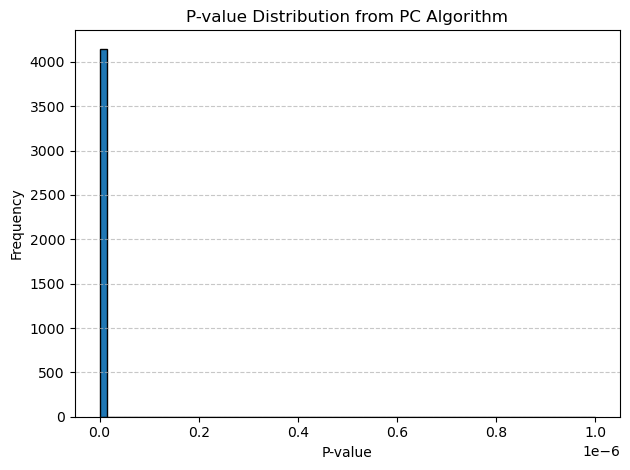

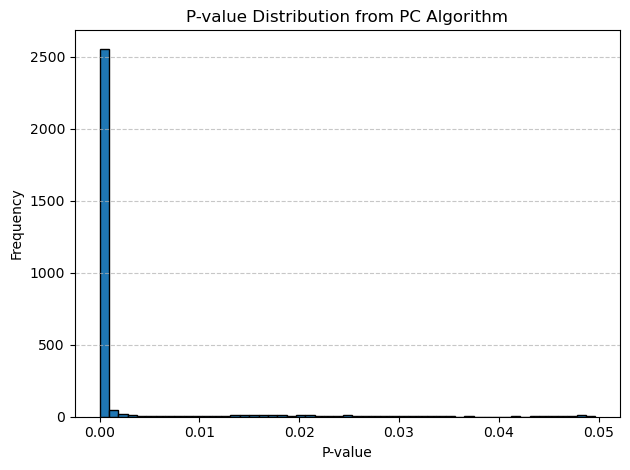


SELECTION PROBABILITY VISUALIZATION


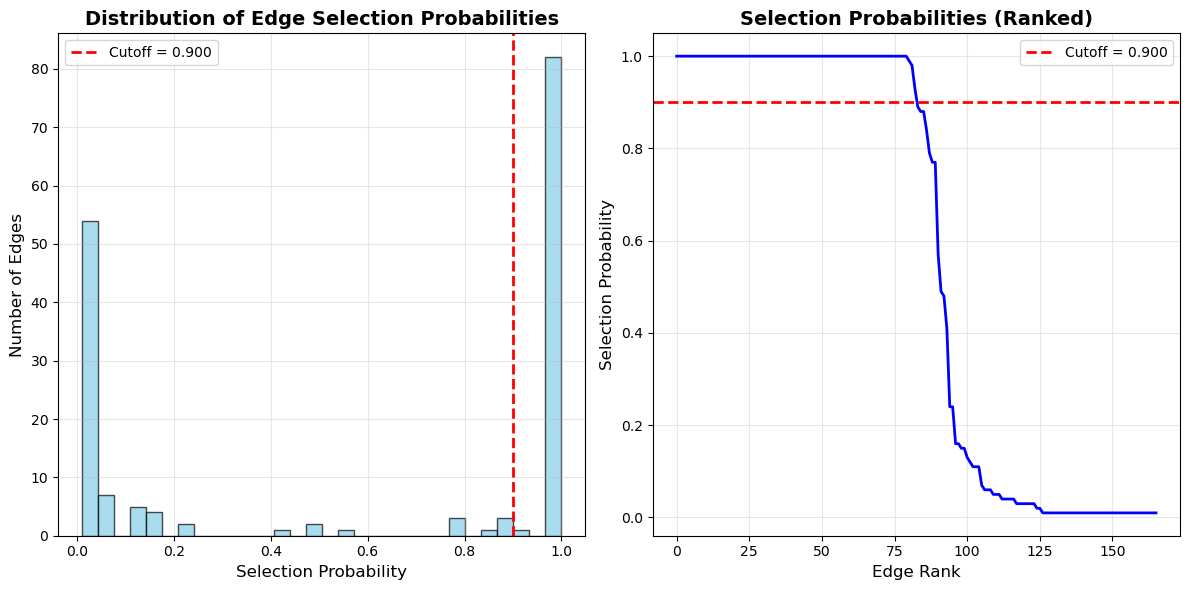


SUMMARY
Dataset shape: (1000, 100)
Total unique edges discovered: 166
Stable edges (≥ 0.900): 83
Unstable edges (< 0.900): 83
P-values from stable edges: 4151
P-values from unstable edges: 2905
Stable edges - Mean p-value: 0.000000
Stable edges - Significant (p < 0.05): 4151/4151 (100.0%)
Unstable edges - Mean p-value: 0.002260
Unstable edges - Significant (p < 0.05): 2905/2905 (100.0%)


In [6]:
project_root = Path('./').resolve().parents[2]
# base_dir = os.path.join(project_root, 'mastersResearch_Jun_Sept2025', 'causalDiscovery_J', 'motivationAnalysis')
# meta_file = os.path.join(base_dir, 'motivation_dag_2.csv')
base_dir = os.path.join(project_root, 'mastersResearch_Jun_Sept2025', 'causalDiscovery_J', 'dataGen','loop100data')
meta_file = os.path.join(base_dir, 'dag2dataset1.csv')
data = pd.read_csv(meta_file).to_numpy()

# Set random seed for reproducibility
np.random.seed(42)

# Run stability selection
full_verbose_output, edge_counts, selection_probabilities, subsample_edge_counts = stability_selection(
    data, n_subsamples=100, subsample_ratio=0.5, alpha=0.05, indep_test='fisherz'
)

# Select stable edges
stable_edges, unstable_edges, cutoff_used = select_stable_edges(
    data.shape[1], selection_probabilities, subsample_edge_counts
)

# Get p-values categorized by stable/unstable edges and full graph
print("\nAnalyzing p-values from stable vs unstable edges...")
stable_pvalues, unstable_pvalues, full_graph = get_pvalues_by_stability(
    stable_edges, unstable_edges, full_verbose_output
)

plot_p_value_distribution(stable_pvalues)
plot_p_value_distribution(unstable_pvalues)

# Visualize selection probabilities with cutoff
print("\n" + "="*60)
print("SELECTION PROBABILITY VISUALIZATION")
print("="*60)
plot_selection_probabilities(selection_probabilities, cutoff=cutoff_used)

print(f"\n" + "="*60)
print("SUMMARY")
print("="*60)
print(f"Dataset shape: {data.shape}")
print(f"Total unique edges discovered: {len(selection_probabilities)}")
print(f"Stable edges (≥ {cutoff_used:.3f}): {len(stable_edges)}")
print(f"Unstable edges (< {cutoff_used:.3f}): {len(unstable_edges)}")
print(f"P-values from stable edges: {len(stable_pvalues)}")
print(f"P-values from unstable edges: {len(unstable_pvalues)}")

if len(stable_pvalues) > 0:
    print(f"Stable edges - Mean p-value: {np.mean(stable_pvalues):.6f}")
    print(f"Stable edges - Significant (p < 0.05): {np.sum(np.array(stable_pvalues) < 0.05)}/{len(stable_pvalues)} ({np.sum(np.array(stable_pvalues) < 0.05)/len(stable_pvalues)*100:.1f}%)")

if len(unstable_pvalues) > 0:
    print(f"Unstable edges - Mean p-value: {np.mean(unstable_pvalues):.6f}")
    print(f"Unstable edges - Significant (p < 0.05): {np.sum(np.array(unstable_pvalues) < 0.05)}/{len(unstable_pvalues)} ({np.sum(np.array(unstable_pvalues) < 0.05)/len(unstable_pvalues)*100:.1f}%)")

In [7]:
def plot_stable_graph(stable_edges, n_nodes, layout="dot", figsize=(12, 12), node_size=500):
    """
    Plot the final stable graph using Graphviz layout (via pydot).

    Parameters:
    -----------
    stable_edges : list of tuples
        List of stable edges (u, v)
    n_nodes : int
        Total number of nodes in the dataset
    layout : str
        Graphviz layout engine ("dot", "neato", "fdp", "sfdp", "circo", "twopi")
    figsize : tuple
        Size of the figure
    node_size : int
        Size of the nodes in the plot
    """
    G = nx.Graph()
    G.add_nodes_from(range(n_nodes))
    G.add_edges_from(stable_edges)

    try:
        # Use Graphviz layout via pydot
        pos = nx.nx_pydot.graphviz_layout(G, prog=layout)
    except Exception as e:
        print(f"Graphviz layout failed ({e}), falling back to spring_layout")
        pos = nx.spring_layout(G, seed=42)

    plt.figure(figsize=figsize)
    nx.draw_networkx_nodes(G, pos, node_size=node_size, node_color="skyblue", alpha=0.8)
    nx.draw_networkx_edges(G, pos, edge_color="black", alpha=0.7, width=1.5)
    nx.draw_networkx_labels(G, pos, font_size=8, font_color="darkblue")

    plt.title(f"Stable Edges Graph (layout={layout})", fontsize=14, fontweight="bold")
    plt.axis("off")
    plt.show()


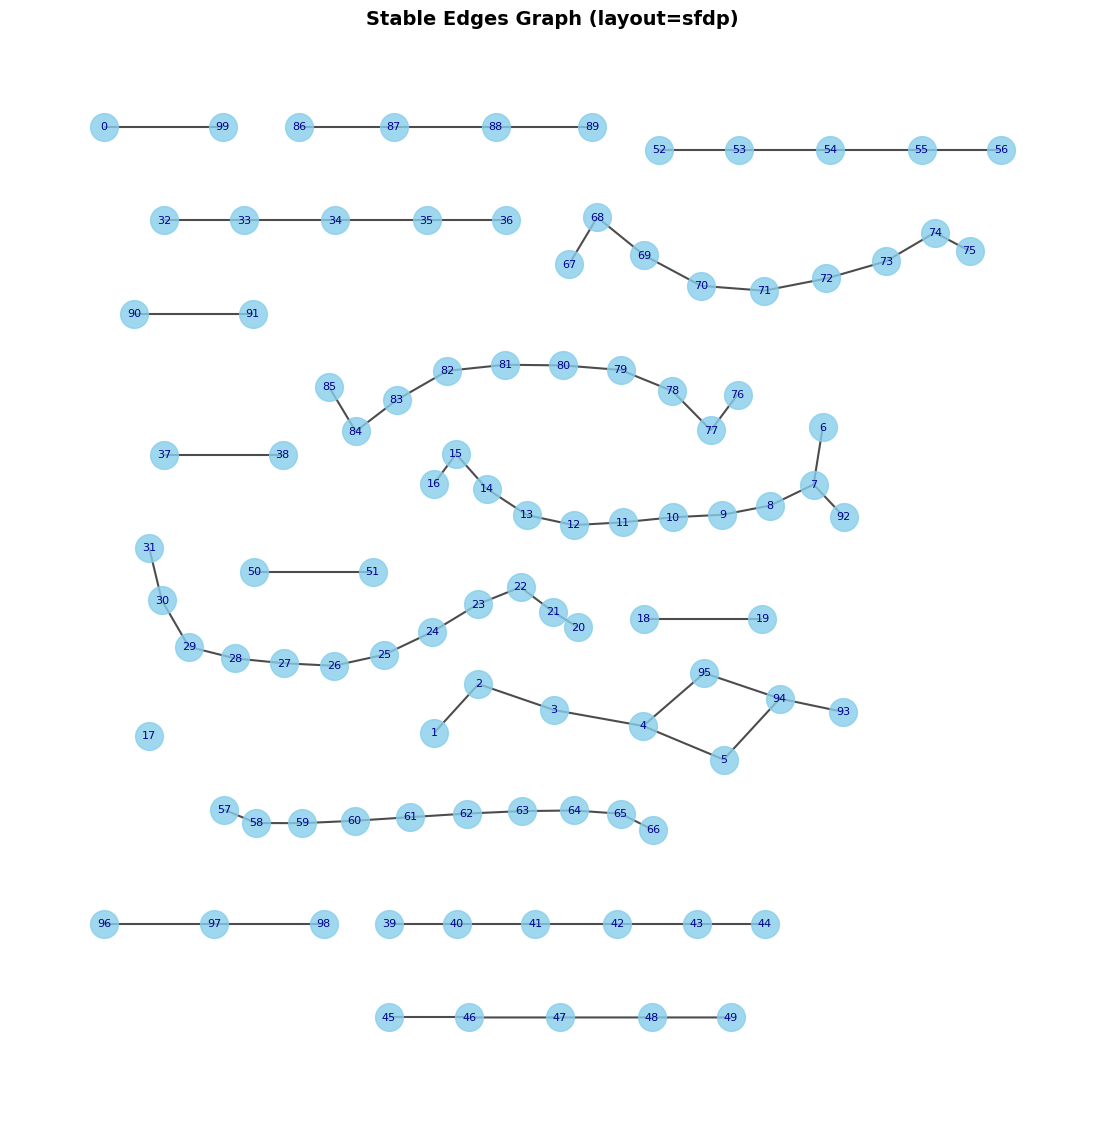

In [8]:
plot_stable_graph(stable_edges, data.shape[1], layout="sfdp", figsize=(14, 14), node_size=400)


Stability Selection Results:
Cutoff threshold: 0.750
Stable edges: 90
Unstable edges: 76

Analyzing p-values from stable vs unstable edges...
Extracting p-values by stability classes...
Stable edges: [(0, 99), (1, 2), (2, 3), (3, 4), (4, 5), (4, 95), (5, 94), (6, 7), (6, 93), (7, 8), (7, 92), (8, 9), (9, 10), (10, 11), (11, 12), (12, 13), (13, 14), (14, 15), (15, 16), (17, 18), (18, 19), (20, 21), (21, 22), (22, 23), (23, 24), (24, 25), (25, 26), (26, 27), (27, 28), (28, 29), (29, 30), (30, 31), (31, 32), (32, 33), (33, 34), (34, 35), (35, 36), (37, 38), (38, 39), (39, 40), (40, 41), (41, 42), (42, 43), (43, 44), (45, 46), (46, 47), (47, 48), (48, 49), (50, 51), (51, 52), (52, 53), (53, 54), (54, 55), (55, 56), (57, 58), (58, 59), (59, 60), (60, 61), (61, 62), (62, 63), (63, 64), (64, 65), (65, 66), (67, 68), (68, 69), (69, 70), (70, 71), (71, 72), (72, 73), (73, 74), (74, 75), (76, 77), (77, 78), (78, 79), (79, 80), (80, 81), (81, 82), (82, 83), (83, 84), (84, 85), (86, 87), (87, 88)

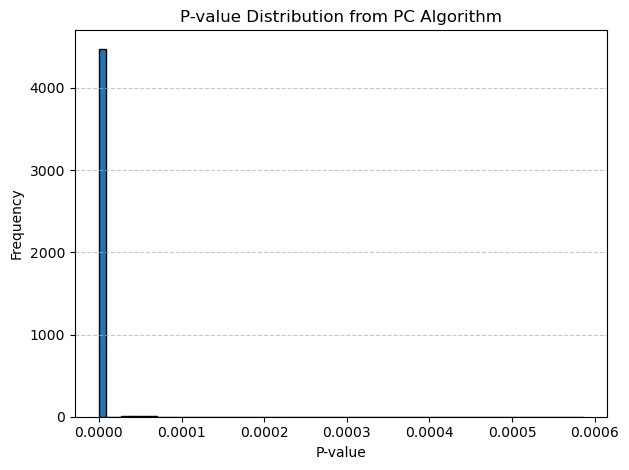

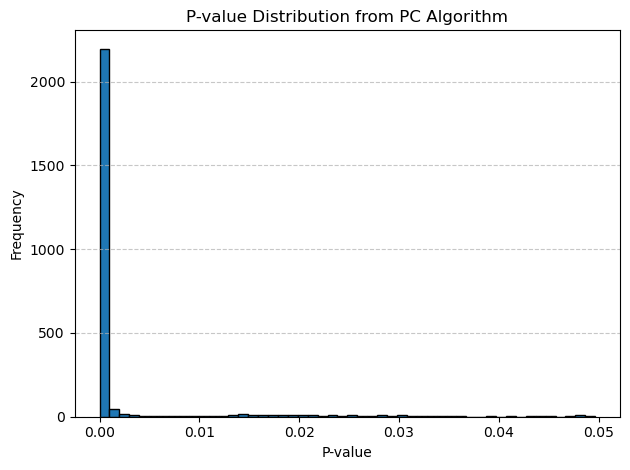


SELECTION PROBABILITY VISUALIZATION


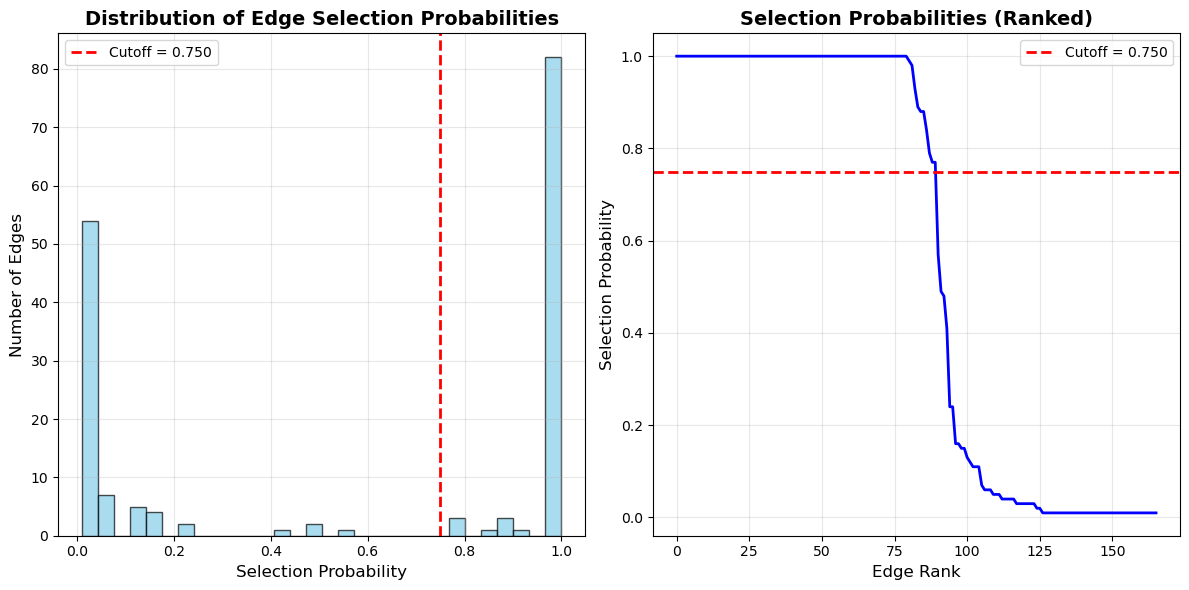


SUMMARY
Dataset shape: (1000, 100)
Total unique edges discovered: 166
Stable edges (≥ 0.750): 90
Unstable edges (< 0.750): 76
P-values from stable edges: 4513
P-values from unstable edges: 2543
Stable edges - Mean p-value: 0.000001
Stable edges - Significant (p < 0.05): 4513/4513 (100.0%)
Unstable edges - Mean p-value: 0.002580
Unstable edges - Significant (p < 0.05): 2543/2543 (100.0%)


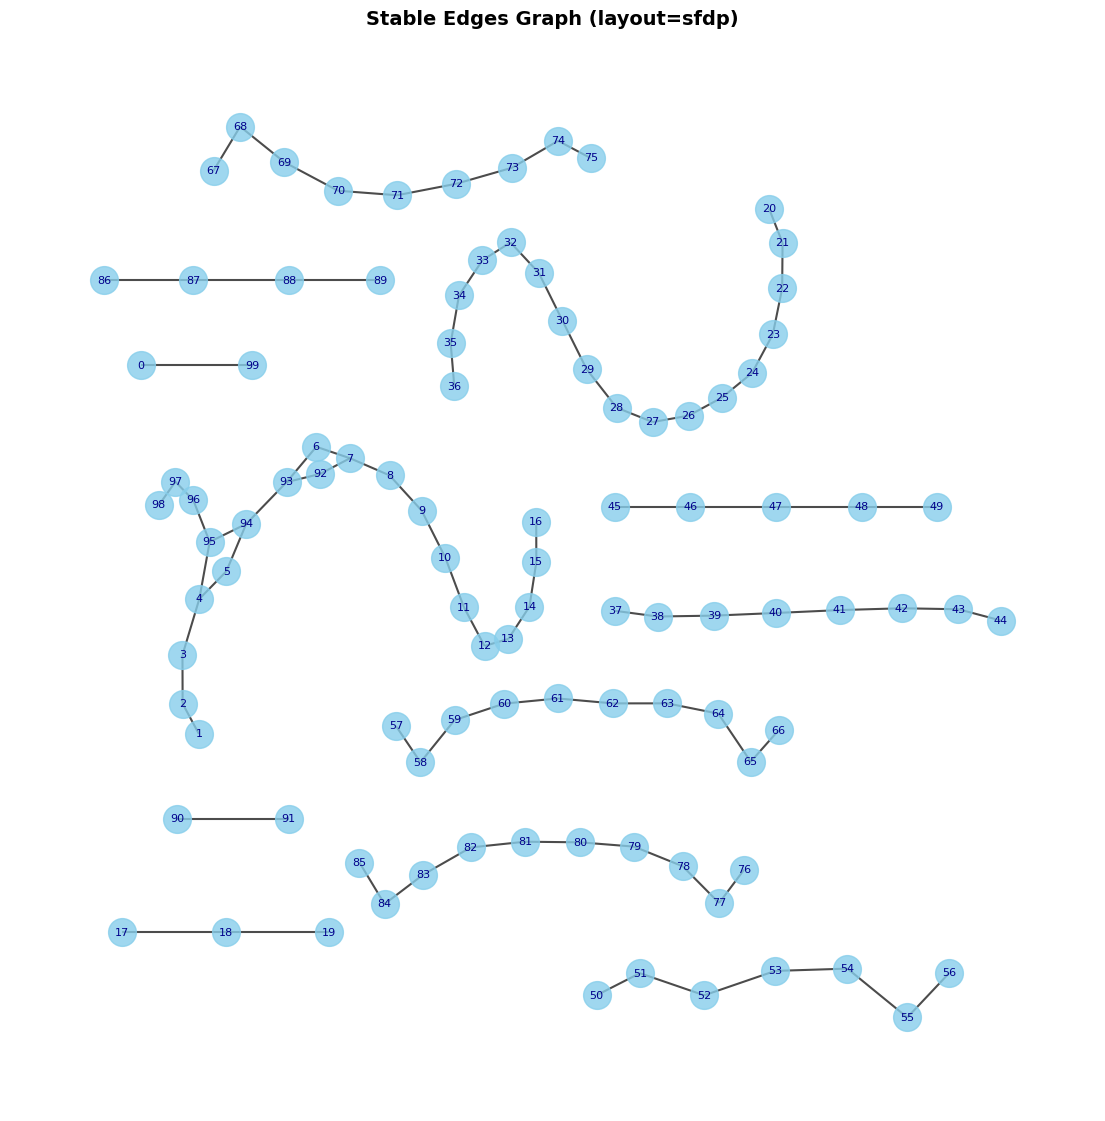

In [11]:
# Select stable edges
stable_edges, unstable_edges, cutoff_used = select_stable_edges(
    data.shape[1], selection_probabilities, subsample_edge_counts, cutoff=0.75
)

# Get p-values categorized by stable/unstable edges and full graph
print("\nAnalyzing p-values from stable vs unstable edges...")
stable_pvalues, unstable_pvalues, full_graph = get_pvalues_by_stability(
    stable_edges, unstable_edges, full_verbose_output
)

plot_p_value_distribution(stable_pvalues)
plot_p_value_distribution(unstable_pvalues)

# Visualize selection probabilities with cutoff
print("\n" + "="*60)
print("SELECTION PROBABILITY VISUALIZATION")
print("="*60)
plot_selection_probabilities(selection_probabilities, cutoff=cutoff_used)

print(f"\n" + "="*60)
print("SUMMARY")
print("="*60)
print(f"Dataset shape: {data.shape}")
print(f"Total unique edges discovered: {len(selection_probabilities)}")
print(f"Stable edges (≥ {cutoff_used:.3f}): {len(stable_edges)}")
print(f"Unstable edges (< {cutoff_used:.3f}): {len(unstable_edges)}")
print(f"P-values from stable edges: {len(stable_pvalues)}")
print(f"P-values from unstable edges: {len(unstable_pvalues)}")

if len(stable_pvalues) > 0:
    print(f"Stable edges - Mean p-value: {np.mean(stable_pvalues):.6f}")
    print(f"Stable edges - Significant (p < 0.05): {np.sum(np.array(stable_pvalues) < 0.05)}/{len(stable_pvalues)} ({np.sum(np.array(stable_pvalues) < 0.05)/len(stable_pvalues)*100:.1f}%)")

if len(unstable_pvalues) > 0:
    print(f"Unstable edges - Mean p-value: {np.mean(unstable_pvalues):.6f}")
    print(f"Unstable edges - Significant (p < 0.05): {np.sum(np.array(unstable_pvalues) < 0.05)}/{len(unstable_pvalues)} ({np.sum(np.array(unstable_pvalues) < 0.05)/len(unstable_pvalues)*100:.1f}%)")

plot_stable_graph(stable_edges, data.shape[1], layout="sfdp", figsize=(14, 14), node_size=400)